# Titanic Survival Analysis
## Exploratory Data Analysis

**GOAL:** Understand what factors determined survival among the 891 passengers aboard the Titanic on April 15, 1912. 

**Questions we will answer:**
1. What was the overall survival rate?
2. Did sex determine survival?
3. Did passenger class determine survival?
4. Did age matter?
5. Did.family size matter?



In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

## Step 1 - Loading and first look at the data

In [21]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The dataset has 12 colums. Survived is our target variable (0 or 1)

In [22]:
print("Rows and columns: ", df.shape)
print("\nColumn names: ", df.columns.tolist())
print("\nData Types: ")
print(df.dtypes)

Rows and columns:  (891, 12)

Column names:  ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types: 
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


# Missing Data:

In [23]:
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing Percent': missing_percent
})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percent', ascending=False)
print(missing_df)

          Missing Count  Missing Percent
Cabin               687        77.104377
Age                 177        19.865320
Embarked              2         0.224467


### Missing Data Observation:

- **Cabin:** 77% missing - Too incomplete
- **Age:** ~20% missing - significant but still usable
- **Embarked:** 0.2% missing - safely use

Does this mean that age is missing randomly or was there bias invovled? <br>
   1. was age missed randomly or, <br>
   2. was age mostly missed from a particular population of the group/age group? Which shows a pattern 

## Statistical Summary:

In [24]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


From this we can say the following: 

* Average Age of passengers : 30 
* Fare: \
  Average : 32 \
  Highest Fare : 512 
  Huge range 
* Survival rate : 38% survived


---
## Step 2 - Analysing variables:

### Variable 1: Survived (Target Variable)
**Type:** Binary (0 = Died, 1 = survived) \
**Question:** What was the overall survival rate?

In [25]:
print("Survival Counts:")
print(df['Survived'].value_counts())

print("\nSurvival rates:")
print(df['Survived'].value_counts(normalize=True).round(3) * 100)
 

Survival Counts:
Survived
0    549
1    342
Name: count, dtype: int64

Survival rates:
Survived
0    61.6
1    38.4
Name: proportion, dtype: float64


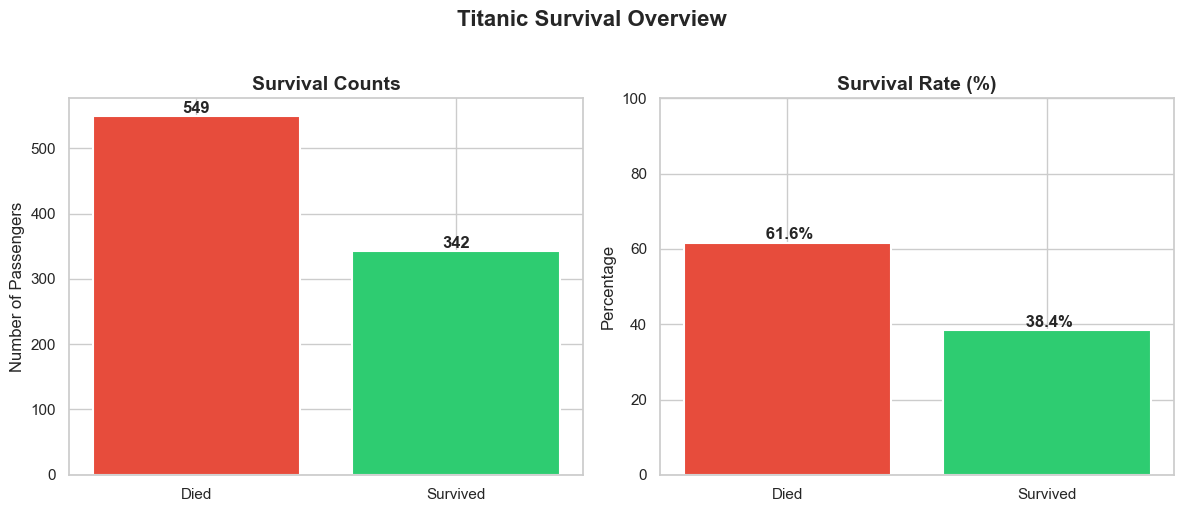

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Left Chart - raw counts:
axes[0].bar(['Died', 'Survived'],
            df['Survived'].value_counts().values,
            color=['#e74c3c', '#2ecc71'],
            edgecolor='white',
            linewidth=1.5)
axes[0].set_title('Survival Counts', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Passengers')

for i, v in enumerate(df['Survived'].value_counts().values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

#Right Chart - percentages:
survival_pct= df['Survived'].value_counts(normalize=True) * 100
axes[1].bar(['Died', 'Survived'], 
            survival_pct.values,
            color=['#e74c3c', '#2ecc71'],
            edgecolor='white',
            linewidth=1.5)
axes[1].set_title('Survival Rate (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Percentage')
axes[1].set_ylim(0, 100)

for i, v in enumerate(survival_pct.values):
    axes[1].text(i, v + 1, f'{v: .1f}%', ha='center', fontweight='bold')

plt.suptitle('Titanic Survival Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()